In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [18]:
data = pd.read_excel(r'D:\StockPrice\data\raw_data.xlsx', index_col='Date')
data.index = pd.to_datetime(data.index)
data = data.drop(data.index[0])

In [19]:
org_data = data.copy()
price_and_volume_cols = ['FPT_Close','FPT_Volume', 'HPG_Close', 'HPG_Volume', 'VCB_Close', 'VCB_Volume', 'TCB_Close', 'TCB_Volume', 'MWG_Close', 'MWG_Volume', 'VNINDEX_Close',	'VNINDEX_Volume']
targets_data = org_data[price_and_volume_cols]

events = org_data[['IsHoliday', 'DayOfWeek', 'DowSin', 'DowCos', 'Holiday_Window', 'Days_To_Holiday']]

In [20]:
targets_data

,FPT_Close,FPT_Volume,HPG_Close,HPG_Volume,VCB_Close,VCB_Volume,TCB_Close,TCB_Volume,MWG_Close,MWG_Volume,VNINDEX_Close,VNINDEX_Volume
Date,,,,,,,,,,,,
2019-01-02,12743.988281,1218959,7239.482910,16681133,34551.597656,1629983.0,24057.296875,1329030.0,25123.429688,1055190.0,891.75,91857070.0
2019-01-03,12620.260742,1902566,6933.920410,27340066,34551.597656,1614477.0,23493.455078,1811430.0,24388.828125,2109180.0,878.22,135125060.0
2019-01-04,12713.056641,845800,6980.929199,23220796,35067.292969,1970058.0,23446.468750,2970830.0,24565.130859,1296510.0,880.90,117664070.0
2019-01-07,12929.579102,1084484,6898.662598,9894167,35196.214844,1771893.0,23587.429688,1436930.0,24976.513672,1194000.0,889.64,87417130.0
2019-01-08,12991.442383,784974,6781.138672,12524614,35454.062500,1987388.0,23587.429688,843170.0,24682.669922,516540.0,887.44,92128530.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-25,72501.359375,10441000,24100.000000,26989100,63700.000000,5410300.0,32550.000000,6800800.0,78700.000000,2510300.0,1886.03,702575224.0
2026-05-26,73487.773438,5104800,24250.000000,20723700,64400.000000,5623900.0,32900.000000,5439700.0,78500.000000,2518800.0,1884.18,729758151.0
2026-05-27,72600.000000,9176300,24150.000000,23114500,64200.000000,4185600.0,33650.000000,16305800.0,80000.000000,4631100.0,1874.43,830501943.0


In [22]:
forward_fill = (targets_data[price_and_volume_cols].replace(0, np.nan))
forward_fill = forward_fill.ffill()
forward_fill.isna().sum()

FPT_Close         0
FPT_Volume        0
HPG_Close         0
HPG_Volume        0
VCB_Close         0
VCB_Volume        0
TCB_Close         0
TCB_Volume        0
MWG_Close         0
MWG_Volume        0
VNINDEX_Close     0
VNINDEX_Volume    0
dtype: int64

In [25]:
linear = (targets_data[price_and_volume_cols].replace(0, np.nan))
linear = linear.interpolate(method='linear')
linear.isna().sum()

FPT_Close         0
FPT_Volume        0
HPG_Close         0
HPG_Volume        0
VCB_Close         0
VCB_Volume        0
TCB_Close         0
TCB_Volume        0
MWG_Close         0
MWG_Volume        0
VNINDEX_Close     0
VNINDEX_Volume    0
dtype: int64

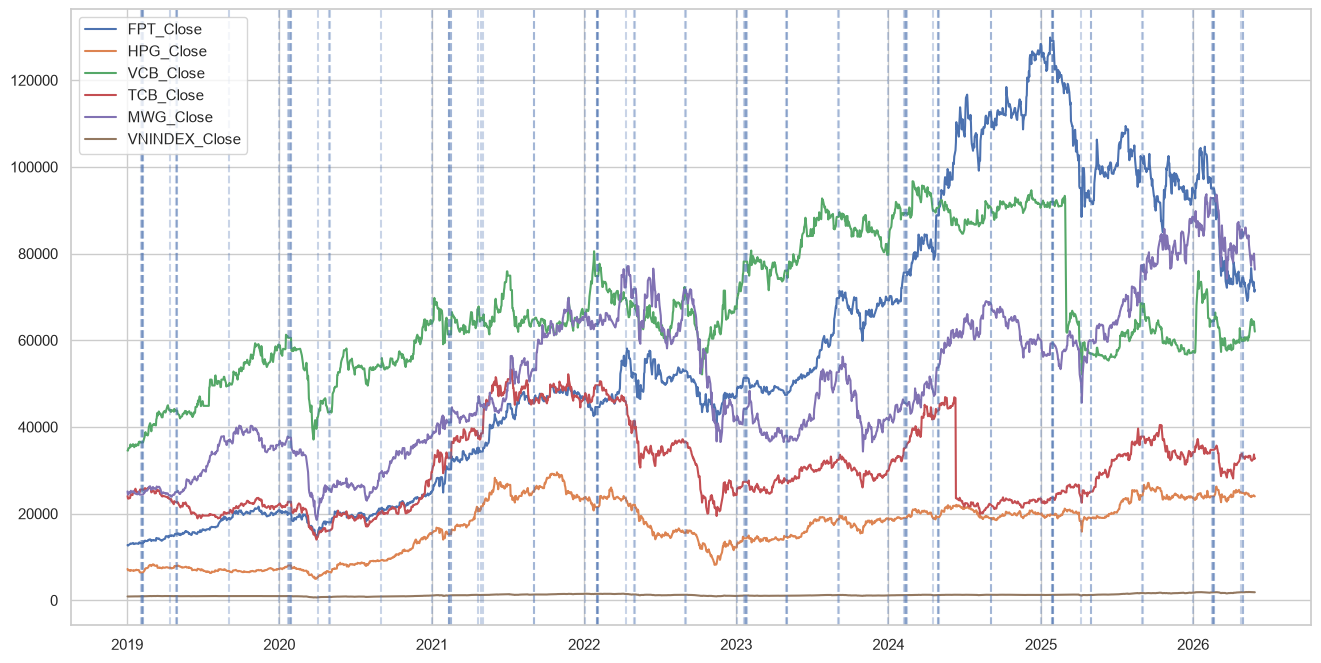

In [32]:
plt.figure(figsize=(16, 8))

# Vẽ giá
for col in linear.columns:
    if 'Close' in col:
        plt.plot(linear.index, linear[col], label=col)

# Lấy các ngày lễ
holiday_dates = events.loc[events['IsHoliday'] == 1].index

# Đánh dấu ngày lễ
for date in holiday_dates:
    plt.axvline(x=date, linestyle='--', alpha=0.3)

plt.legend()
plt.show()

In [64]:
# Lấy các cột Close
close_cols = [col for col in price_and_volume_cols if 'Close' in col]

# Tạo daily returns
daily_returns = (np.log(data[close_cols] / data[close_cols].shift(1))) * 100
daily_returns = daily_returns.drop(daily_returns.index[0])

for col in close_cols:
    daily_returns.rename(columns={col:f'{col}_ret'}, inplace=True)
daily_returns

,FPT_Close_ret,HPG_Close_ret,VCB_Close_ret,TCB_Close_ret,MWG_Close_ret,VNINDEX_Close_ret
Date,,,,,,
2019-01-03,-0.975614,-4.312441,0.000000,-2.371648,-2.967570,-1.528869
2019-01-04,0.732603,0.675666,1.481508,-0.200198,0.720283,0.304698
2019-01-07,1.688809,-1.185446,0.366967,0.599403,1.660794,0.987277
2019-01-08,0.477322,-1.718253,0.729930,0.000000,-1.183456,-0.247597
2019-01-09,0.947886,2.228034,1.444079,2.750663,1.652927,1.070380
...,...,...,...,...,...,...
2026-05-25,-2.153511,0.605377,0.314466,1.081092,-0.885521,0.473008
2026-05-26,1.351373,0.620478,1.092907,1.069529,-0.254453,-0.098138
2026-05-27,-1.215412,-0.413224,-0.311042,2.254040,1.892801,-0.518810


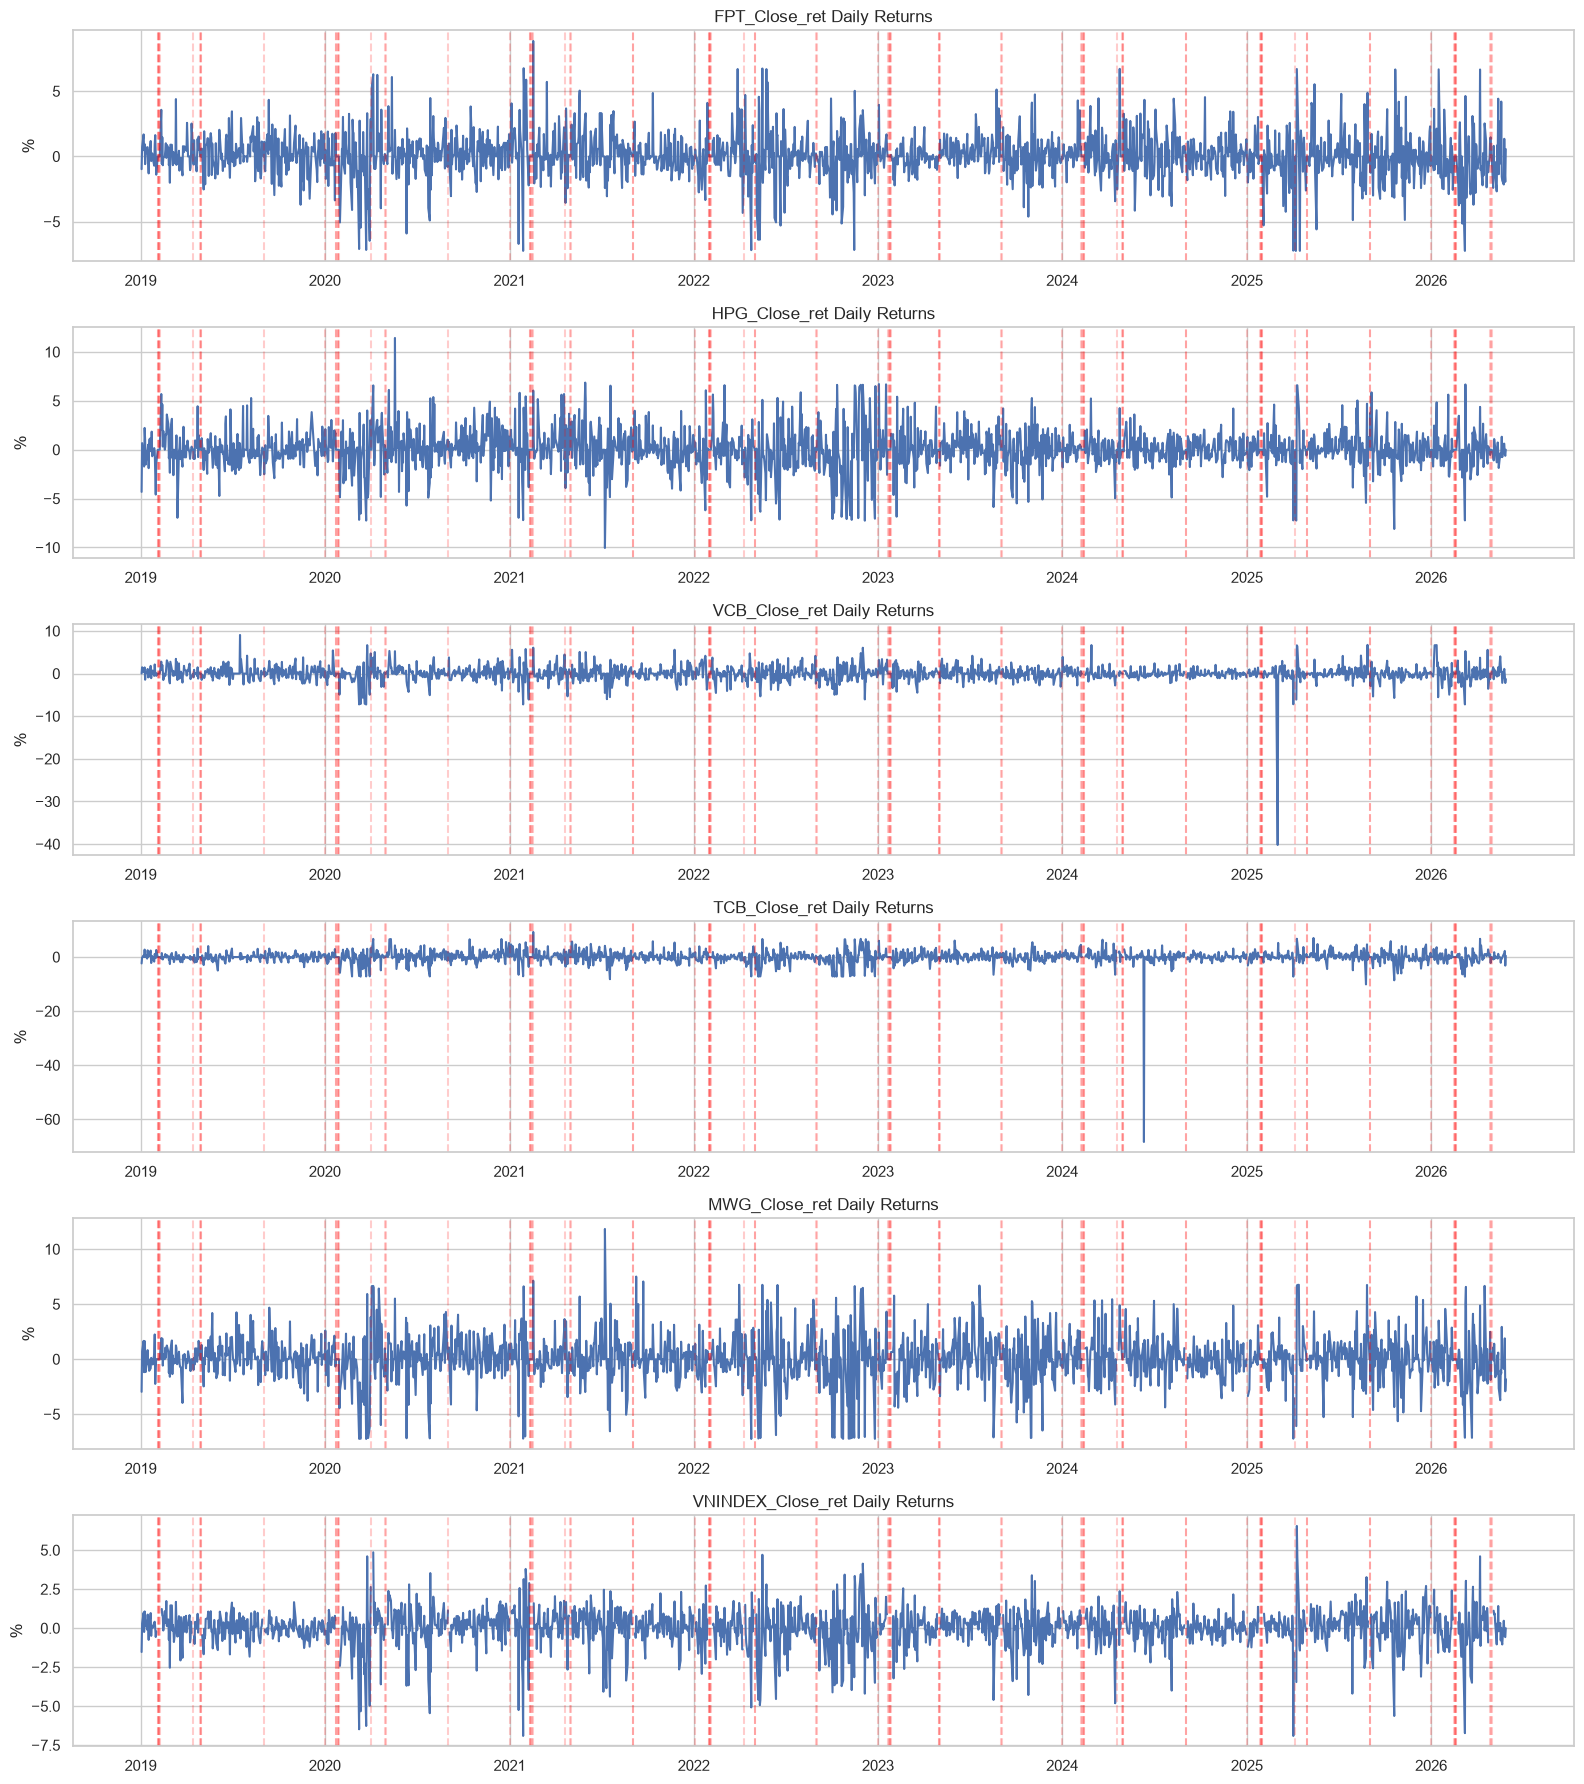

In [66]:
fig, axes = plt.subplots(len(close_cols), 1, figsize=(16, 3*len(close_cols)))
new_cols = daily_returns.columns

holiday_dates = events.index[events['IsHoliday'] == 1]

for i, col in enumerate(new_cols):
    axes[i].plot(daily_returns.index, daily_returns[col])
    axes[i].set_title(f'{col} Daily Returns')
    axes[i].set_ylabel('%')

    for date in holiday_dates:
        axes[i].axvline(date, linestyle='--', alpha=0.2, color='red')

plt.tight_layout()
plt.show()

In [ ]:
def generate_signal(features):
    signal = pd.DataFrame(index=features.index)

    market = features['VNINDEX_Close_ret']

    for col in features.columns:
        if col.endswith('_ret') and col != 'VNINDEX_Close_ret':

            stock = features[col]

            signal[col.replace('_Close_ret', '')] = (
                (stock > 0.002) &
                (stock > stock.rolling(3).mean()) &
                (market > 0)
            ).astype(int)

    return signal

signal = generate_signal(daily_returns) 

,FPT,HPG,VCB,TCB,MWG
Date,,,,,
2019-01-03,0,0,0,0,0
2019-01-04,0,0,0,0,0
2019-01-07,1,0,0,1,1
2019-01-08,0,0,0,0,0
2019-01-09,0,1,1,1,1
...,...,...,...,...,...
2026-05-25,0,1,1,1,0
2026-05-26,0,0,0,0,0
2026-05-27,0,0,0,0,0
